In [1]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import json
import time
import os
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, mean_absolute_error
from groq import Groq

In [ ]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if GROQ_API_KEY == "your_api_key_here":
    raise ValueError(
        "⚠️ Please set your GROQ_API_KEY!\n"
        "Option 1: export GROQ_API_KEY='your_key'\n"
        "Option 2: Replace 'your_api_key_here' in the code"
    )

try:
    client = Groq(api_key=GROQ_API_KEY)
    print("✅ Groq client initialized successfully")
except Exception as e:
    raise ValueError(f"❌ Failed to initialize Groq client: {e}")

MODEL_NAME = "llama-3.1-8b-instant"
SAMPLE_SIZE = 200
DELAY_BETWEEN_REQUESTS = 7.0  # Increased to 7 seconds for safety
MAX_RETRIES = 6  # Increased retries
BASE_RETRY_DELAY = 10  # Longer initial delay
MAX_REVIEW_LENGTH = 120  # Reduced to save tokens
MAX_RESPONSE_TOKENS = 200


✅ Groq client initialized successfully


In [4]:
def enhanced_expert_prompt(review_text):
    """
    Enhanced Expert Sentiment Analyst Prompt
    Ultra-strict JSON formatting to guarantee valid output
    """
    # Safe truncation
    if not isinstance(review_text, str):
        review_text = str(review_text)

    # Clean the review text
    review_text = review_text.strip()
    review_text = re.sub(r'\s+', ' ', review_text)  # Normalize whitespace

    # Truncate if needed
    words = review_text.split()
    if len(words) > MAX_REVIEW_LENGTH:
        review_short = ' '.join(words[:MAX_REVIEW_LENGTH]) + "..."
    else:
        review_short = review_text

    # Escape special characters for JSON safety
    review_short = review_short.replace('"', "'").replace('\n', ' ').replace('\r', '')

    prompt = f"""You are an expert sentiment analyst. Rate the following review on a 1-5 star scale.

**Rating Guidelines:**
5 = Extremely positive, delighted, highly recommending
4 = Positive with minor flaws, satisfied
3 = Neutral/mixed, okay but not memorable
2 = Mostly negative, disappointed
1 = Very negative, angry, strongly discouraging

**Examples:**
- "Amazing experience, will definitely return!" → 5 stars
- "Good but overpriced." → 4 stars
- "It was okay, nothing special." → 3 stars
- "Disappointing, wouldn't come back." → 2 stars
- "Terrible service and food." → 1 star

**Review:**
"{review_short}"

**Analysis Steps:**
1. Identify sentiment (positive/neutral/negative)
2. Determine intensity (weak/moderate/strong)
3. Note specific praises or complaints
4. Match to star rating (1-5)

CRITICAL: Respond with ONLY valid JSON. No other text before or after. Use this EXACT format:
{{"predicted_stars": 3, "explanation": "brief reason"}}

Do NOT include any text outside the JSON object. Start your response with {{ and end with }}.
"""

    return prompt

In [5]:
def call_groq_api_safe(prompt, request_number=0):
    """
    Ultra-safe API call with comprehensive error handling and JSON validation
    GUARANTEED to return a valid response or detailed error
    """

    for attempt in range(MAX_RETRIES):
        try:
            # Make API call
            chat_completion = client.chat.completions.create(
                messages=[{
                    "role": "user",
                    "content": prompt
                }],
                model=MODEL_NAME,
                temperature=0.2,  # Lower for more consistent output
                max_tokens=MAX_RESPONSE_TOKENS,
            )

            response_text = chat_completion.choices[0].message.content.strip()

            # Multiple strategies to extract JSON
            json_result = None

            # Strategy 1: Direct JSON parsing
            if response_text.startswith('{') and response_text.endswith('}'):
                try:
                    json_result = json.loads(response_text)
                except:
                    pass

            # Strategy 2: Find JSON in text
            if json_result is None and '{' in response_text and '}' in response_text:
                try:
                    start_idx = response_text.find('{')
                    end_idx = response_text.rfind('}') + 1
                    json_str = response_text[start_idx:end_idx]

                    # Clean JSON string
                    json_str = json_str.replace('\n', ' ').replace('\r', ' ')
                    json_str = re.sub(r'\s+', ' ', json_str)

                    json_result = json.loads(json_str)
                except:
                    pass

            # Strategy 3: Fix common JSON issues
            if json_result is None and '{' in response_text:
                try:
                    start_idx = response_text.find('{')
                    end_idx = response_text.rfind('}') + 1
                    json_str = response_text[start_idx:end_idx]

                    # Replace single quotes with double quotes
                    json_str = json_str.replace("'", '"')
                    # Remove trailing commas
                    json_str = re.sub(r',(\s*[}\]])', r'\1', json_str)
                    # Fix common issues
                    json_str = json_str.replace('\n', ' ').replace('\r', ' ')

                    json_result = json.loads(json_str)
                except:
                    pass

            # Strategy 4: Extract using regex
            if json_result is None:
                try:
                    # Look for "predicted_stars": N pattern
                    stars_match = re.search(r'"?predicted_stars"?\s*:\s*(\d+)', response_text)
                    explanation_match = re.search(r'"?explanation"?\s*:\s*"([^"]+)"', response_text)

                    if stars_match:
                        stars = int(stars_match.group(1))
                        explanation = explanation_match.group(1) if explanation_match else "extracted from response"

                        if 1 <= stars <= 5:
                            json_result = {
                                "predicted_stars": stars,
                                "explanation": explanation
                            }
                except:
                    pass

            # Validate JSON result
            if json_result:
                # Find stars field (flexible naming)
                stars_value = None
                for key in ['predicted_stars', 'stars', 'rating', 'star_rating', 'score']:
                    if key in json_result:
                        try:
                            stars_value = int(json_result[key])
                            break
                        except:
                            continue

                # Find explanation field
                explanation_value = None
                for key in ['explanation', 'reason', 'reasoning', 'analysis', 'why']:
                    if key in json_result:
                        explanation_value = str(json_result[key])
                        break

                # Validate stars range
                if stars_value and 1 <= stars_value <= 5:
                    if explanation_value:
                        return {
                            'success': True,
                            'predicted_stars': stars_value,
                            'explanation': explanation_value[:500]  # Limit length
                        }
                    else:
                        return {
                            'success': True,
                            'predicted_stars': stars_value,
                            'explanation': 'No explanation provided'
                        }

            # If we get here, JSON parsing failed
            if attempt < MAX_RETRIES - 1:
                print(f"\n⚠️  Request #{request_number}, attempt {attempt+1}: Invalid JSON, retrying...")
                time.sleep(3)
                continue
            else:
                return {
                    'success': False,
                    'error': 'Failed to parse JSON after all attempts',
                    'raw_response': response_text[:300]
                }

        except Exception as e:
            error_str = str(e)

            # Handle rate limiting
            if '429' in error_str or 'rate_limit' in error_str.lower() or 'rate limit' in error_str.lower():
                wait_time = BASE_RETRY_DELAY * (2 ** attempt)
                print(f"\n⚠️  Rate limit at request #{request_number}! Waiting {wait_time}s... (attempt {attempt+1}/{MAX_RETRIES})")
                time.sleep(wait_time)
                continue

            # Handle other API errors
            if 'api' in error_str.lower() or 'connection' in error_str.lower():
                if attempt < MAX_RETRIES - 1:
                    wait_time = 5 * (attempt + 1)
                    print(f"\n⚠️  API error at request #{request_number}: {error_str[:100]}")
                    print(f"   Retrying in {wait_time}s... (attempt {attempt+1}/{MAX_RETRIES})")
                    time.sleep(wait_time)
                    continue

            # Final attempt failed
            if attempt >= MAX_RETRIES - 1:
                return {
                    'success': False,
                    'error': f'API error after {MAX_RETRIES} attempts: {error_str[:200]}',
                    'raw_response': ''
                }

    return {
        'success': False,
        'error': f'All {MAX_RETRIES} retry attempts exhausted',
        'raw_response': ''
    }

In [6]:
def evaluate_enhanced_prompt(df, sample_size=200):
    """Evaluate with detailed progress tracking and error recovery"""

    print(f"\n{'='*80}")
    print(f"🎯 ENHANCED EXPERT SENTIMENT ANALYSIS")
    print(f"{'='*80}")
    print(f"📊 Sample size: {sample_size}")
    print(f"⏱️  Delay: {DELAY_BETWEEN_REQUESTS}s between requests")
    print(f"🔄 Max retries: {MAX_RETRIES} per request")
    print(f"⏰ Est. time: ~{(sample_size * DELAY_BETWEEN_REQUESTS) / 60:.1f} minutes")
    print(f"   (May be longer with retries)")
    print(f"{'='*80}\n")

    df_sample = df.head(sample_size).copy().reset_index(drop=True)

    results = []
    json_valid_count = 0
    correct_predictions = 0
    total_abs_error = 0
    all_actuals = []
    all_predicted = []
    failed_samples = []

    start_time = time.time()

    print("🚀 Starting evaluation...\n")

    for idx in range(len(df_sample)):
        row = df_sample.iloc[idx]
        sample_num = idx + 1

        # Progress tracking
        elapsed = time.time() - start_time
        avg_time = elapsed / sample_num
        remaining = (sample_size - sample_num) * avg_time
        current_accuracy = (correct_predictions / sample_num * 100) if sample_num > 0 else 0
        current_mae = (total_abs_error / json_valid_count) if json_valid_count > 0 else 0

        print(f"[{sample_num}/{sample_size}] "
              f"Elapsed: {elapsed/60:.1f}m | "
              f"ETA: ~{remaining/60:.1f}m | "
              f"Acc: {current_accuracy:.1f}% | "
              f"MAE: {current_mae:.2f} | "
              f"Valid: {json_valid_count}/{sample_num} | "
              f"Failed: {len(failed_samples)}",
              end='\r')

        # Generate prompt
        try:
            prompt = enhanced_expert_prompt(row['text'])
        except Exception as e:
            print(f"\n❌ Sample {sample_num}: Prompt generation failed: {str(e)[:100]}")
            results.append({
                'sample_id': sample_num,
                'review_text': str(row['text'])[:100] + "...",
                'actual_stars': int(row['stars']),
                'predicted_stars': None,
                'explanation': '',
                'json_valid': False,
                'error': f'Prompt error: {str(e)[:100]}'
            })
            failed_samples.append(sample_num)
            continue

        # Call API
        response = call_groq_api_safe(prompt, request_number=sample_num)

        # Record result
        result = {
            'sample_id': sample_num,
            'review_text': str(row['text'])[:100] + "...",
            'actual_stars': int(row['stars']),
            'predicted_stars': None,
            'explanation': '',
            'json_valid': response['success'],
            'error': response.get('error', '')
        }

        if response['success']:
            json_valid_count += 1
            predicted = response['predicted_stars']
            result['predicted_stars'] = predicted
            result['explanation'] = response['explanation']

            all_actuals.append(int(row['stars']))
            all_predicted.append(predicted)

            if predicted == int(row['stars']):
                correct_predictions += 1
            total_abs_error += abs(predicted - int(row['stars']))
        else:
            failed_samples.append(sample_num)
            print(f"\n⚠️  Sample {sample_num} FAILED: {response.get('error', 'Unknown error')[:100]}")

        results.append(result)

        # Wait between requests
        time.sleep(DELAY_BETWEEN_REQUESTS)

        # Save progress
        if sample_num % 50 == 0 or sample_num == sample_size:
            try:
                progress_df = pd.DataFrame(results)
                filename = f'enhanced_prompt_checkpoint_{sample_num}.csv'
                progress_df.to_csv(filename, index=False)
                print(f"\n💾 Checkpoint saved: {filename}" + " "*50)
            except Exception as e:
                print(f"\n⚠️  Failed to save checkpoint: {e}")

    print("\n" + "="*80)

    # Calculate final metrics
    total_samples = len(results)
    accuracy = (correct_predictions / total_samples) * 100 if total_samples > 0 else 0
    json_validity = (json_valid_count / total_samples) * 100 if total_samples > 0 else 0
    mae = total_abs_error / json_valid_count if json_valid_count > 0 else 0

    # Print results
    print(f"\n{'='*80}")
    print(f"✅ EVALUATION COMPLETE - FINAL RESULTS")
    print(f"{'='*80}")
    print(f"📊 Total Samples: {total_samples}")
    print(f"✓  Successful: {json_valid_count} ({json_validity:.1f}%)")
    print(f"✗  Failed: {len(failed_samples)} ({(len(failed_samples)/total_samples*100):.1f}%)")
    print(f"{'─'*80}")
    print(f"🎯 Accuracy: {accuracy:.2f}% ({correct_predictions}/{json_valid_count} correct)")
    print(f"📉 Mean Absolute Error: {mae:.2f} stars")
    print(f"⏱️  Total Time: {(time.time() - start_time)/60:.1f} minutes")
    print(f"⚡ Avg Speed: {total_samples/((time.time()-start_time)/60):.1f} samples/min")
    print(f"{'='*80}\n")

    if failed_samples:
        print(f"⚠️  Failed sample IDs: {failed_samples[:20]}{'...' if len(failed_samples) > 20 else ''}\n")

    # Save final results
    try:
        results_df = pd.DataFrame(results)
        results_df.to_csv('enhanced_prompt_FINAL_200samples.csv', index=False)
        print(f"💾 Final results saved: enhanced_prompt_FINAL_200samples.csv\n")
    except Exception as e:
        print(f"⚠️  Failed to save final results: {e}\n")

    return {
        'accuracy': accuracy,
        'json_validity': json_validity,
        'mae': mae,
        'correct': correct_predictions,
        'total': total_samples,
        'actuals': all_actuals,
        'predicted': all_predicted,
        'detailed_results': results,
        'failed_count': len(failed_samples)
    }

# =============================================================================
# COMPREHENSIVE VISUALIZATION
# =============================================================================
def create_visualization(metrics):
    """Create detailed visualization with error handling"""

    print("\n📈 Generating comprehensive visualization...")

    if len(metrics['actuals']) == 0:
        print("⚠️  No valid predictions to visualize")
        return

    try:
        fig = plt.figure(figsize=(20, 12))
        gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

        fig.suptitle(f'Enhanced Expert Prompt - Complete Analysis ({SAMPLE_SIZE} Samples)',
                     fontsize=20, fontweight='bold', y=0.98)

        # 1. Large Confusion Matrix
        ax1 = fig.add_subplot(gs[0:2, 0:2])
        cm = confusion_matrix(metrics['actuals'], metrics['predicted'], labels=[1, 2, 3, 4, 5])
        sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=ax1,
                   xticklabels=['1★', '2★', '3★', '4★', '5★'],
                   yticklabels=['1★', '2★', '3★', '4★', '5★'],
                   cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
        ax1.set_xlabel('Predicted Stars', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Actual Stars', fontsize=14, fontweight='bold')
        ax1.set_title('Confusion Matrix', fontsize=16, fontweight='bold', pad=15)

        # 2. Key Metrics Box
        ax2 = fig.add_subplot(gs[0, 2])
        ax2.axis('off')
        metrics_text = f"""
╔══════════════════════════╗
║     KEY METRICS          ║
╠══════════════════════════╣
║ Accuracy:    {metrics['accuracy']:6.2f}%  ║
║ JSON Valid:  {metrics['json_validity']:6.2f}%  ║
║ MAE:         {metrics['mae']:6.2f}    ║
║ Correct:     {metrics['correct']:3d}/{metrics['total']:3d}  ║
║ Failed:      {metrics['failed_count']:3d}       ║
╠══════════════════════════╣
║ Model: {MODEL_NAME[:15]:15s} ║
╚══════════════════════════╝
"""
        ax2.text(0.05, 0.5, metrics_text, fontsize=11, family='monospace',
                verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5, pad=1))

        # 3. Star Distribution
        ax3 = fig.add_subplot(gs[1, 2])
        stars = [1, 2, 3, 4, 5]
        actual_counts = [metrics['actuals'].count(s) for s in stars]
        predicted_counts = [metrics['predicted'].count(s) for s in stars]

        x = np.arange(len(stars))
        width = 0.35
        bars1 = ax3.bar(x - width/2, actual_counts, width, label='Actual', color='#3498db', alpha=0.8)
        bars2 = ax3.bar(x + width/2, predicted_counts, width, label='Predicted', color='#e74c3c', alpha=0.8)

        ax3.set_xlabel('Star Rating', fontweight='bold', fontsize=12)
        ax3.set_ylabel('Count', fontweight='bold', fontsize=12)
        ax3.set_title('Star Distribution Comparison', fontweight='bold', fontsize=14)
        ax3.set_xticks(x)
        ax3.set_xticklabels([f'{s}★' for s in stars])
        ax3.legend(fontsize=10)
        ax3.grid(axis='y', alpha=0.3, linestyle='--')

        # Add value labels
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax3.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}', ha='center', va='bottom', fontsize=9)

        # 4. Accuracy by Star Rating
        ax4 = fig.add_subplot(gs[2, 0])
        star_accuracies = []
        star_counts = []
        for star in stars:
            actual_star = [a for a, p in zip(metrics['actuals'], metrics['predicted']) if a == star]
            predicted_star = [p for a, p in zip(metrics['actuals'], metrics['predicted']) if a == star]
            star_counts.append(len(actual_star))
            if len(actual_star) > 0:
                correct = sum([1 for a, p in zip(actual_star, predicted_star) if a == p])
                star_accuracies.append((correct / len(actual_star)) * 100)
            else:
                star_accuracies.append(0)

        colors_grad = ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71', '#27ae60']
        bars = ax4.bar(stars, star_accuracies, color=colors_grad, alpha=0.8, edgecolor='black')
        ax4.set_xlabel('Actual Star Rating', fontweight='bold', fontsize=12)
        ax4.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)
        ax4.set_title('Prediction Accuracy by Star Rating', fontweight='bold', fontsize=14)
        ax4.set_ylim(0, 105)
        ax4.set_xticks(stars)
        ax4.set_xticklabels([f'{s}★' for s in stars])
        ax4.grid(axis='y', alpha=0.3, linestyle='--')

        for i, (v, count) in enumerate(zip(star_accuracies, star_counts)):
            ax4.text(stars[i], v + 2, f'{v:.1f}%\n(n={count})',
                    ha='center', fontweight='bold', fontsize=9)

        # 5. Error Distribution
        ax5 = fig.add_subplot(gs[2, 1])
        errors = [abs(a - p) for a, p in zip(metrics['actuals'], metrics['predicted'])]
        error_counts = Counter(errors)
        error_labels = sorted(error_counts.keys())
        error_values = [error_counts[e] for e in error_labels]
        error_pcts = [(v/sum(error_values))*100 for v in error_values]

        bars = ax5.bar(error_labels, error_values, color='#e74c3c', alpha=0.7, edgecolor='black')
        ax5.set_xlabel('Absolute Error (stars)', fontweight='bold', fontsize=12)
        ax5.set_ylabel('Frequency', fontweight='bold', fontsize=12)
        ax5.set_title('Prediction Error Distribution', fontweight='bold', fontsize=14)
        ax5.set_xticks(error_labels)
        ax5.grid(axis='y', alpha=0.3, linestyle='--')

        for bar, pct in zip(bars, error_pcts):
            height = bar.get_height()
            ax5.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

        # 6. Performance Summary
        ax6 = fig.add_subplot(gs[2, 2])
        ax6.axis('off')

        within_1_star = sum([1 for e in errors if e <= 1]) / len(errors) * 100 if errors else 0
        perfect = sum([1 for e in errors if e == 0]) / len(errors) * 100 if errors else 0
        within_2_stars = sum([1 for e in errors if e <= 2]) / len(errors) * 100 if errors else 0

        summary_text = f"""
╔══════════════════════════╗
║  PERFORMANCE SUMMARY     ║
╠══════════════════════════╣
║ Perfect:     {perfect:6.1f}%    ║
║ Within 1★:   {within_1_star:6.1f}%    ║
║ Within 2★:   {within_2_stars:6.1f}%    ║
╠══════════════════════════╣
║ Avg Error:   {metrics['mae']:6.2f}★    ║
║ Success Rate:{metrics['json_validity']:6.1f}%    ║
╠══════════════════════════╣
║ Time: {(time.time() - start_time)/60:8.1f}m     ║
║ Speed: {len(errors)/(time.time()-start_time)*60:7.1f}/min  ║
╚══════════════════════════╝
"""
        ax6.text(0.05, 0.5, summary_text, fontsize=11, family='monospace',
                verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5, pad=1))

        plt.tight_layout()

        # Save with high DPI
        plt.savefig('enhanced_prompt_ANALYSIS_200samples.png', dpi=300, bbox_inches='tight')
        print("✅ Visualization saved: enhanced_prompt_ANALYSIS_200samples.png")

        plt.show()

    except Exception as e:
        print(f"⚠️  Visualization error: {e}")
        import traceback
        traceback.print_exc()


🚀 BATTLE-TESTED ENHANCED SENTIMENT ANALYSIS
✓ Guaranteed JSON parsing
✓ Comprehensive error handling
✓ Automatic retries with backoff
✓ Progress checkpoints every 50 samples

📂 Loading and validating data...
✅ Loaded CSV: 10000 rows
🧹 Cleaning data...
✅ Clean dataset: 9987 valid reviews

⚙️  CONFIGURATION
🤖 Model:           llama-3.1-8b-instant
📊 Samples:         200
📝 Max review len:  120 words
⏱️  Request delay:   7.0s
🔄 Max retries:     6
🌡️  Temperature:     0.2 (low = consistent)
⏰ Est. time:       ~23.3 minutes

🔍 Testing API connection...
✅ API test successful!
   Test prediction: 4 stars

Press ENTER to start evaluation (or Ctrl+C to cancel)...C:\Users\himan\Downloads\archive\yelp.csv

🎯 ENHANCED EXPERT SENTIMENT ANALYSIS
📊 Sample size: 200
⏱️  Delay: 7.0s between requests
🔄 Max retries: 6 per request
⏰ Est. time: ~23.3 minutes
   (May be longer with retries)

🚀 Starting evaluation...


💾 Checkpoint saved: enhanced_prompt_checkpoint_50.csv                                      

/tmp/ipython-input-361048729.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Visualization saved: enhanced_prompt_ANALYSIS_200samples.png


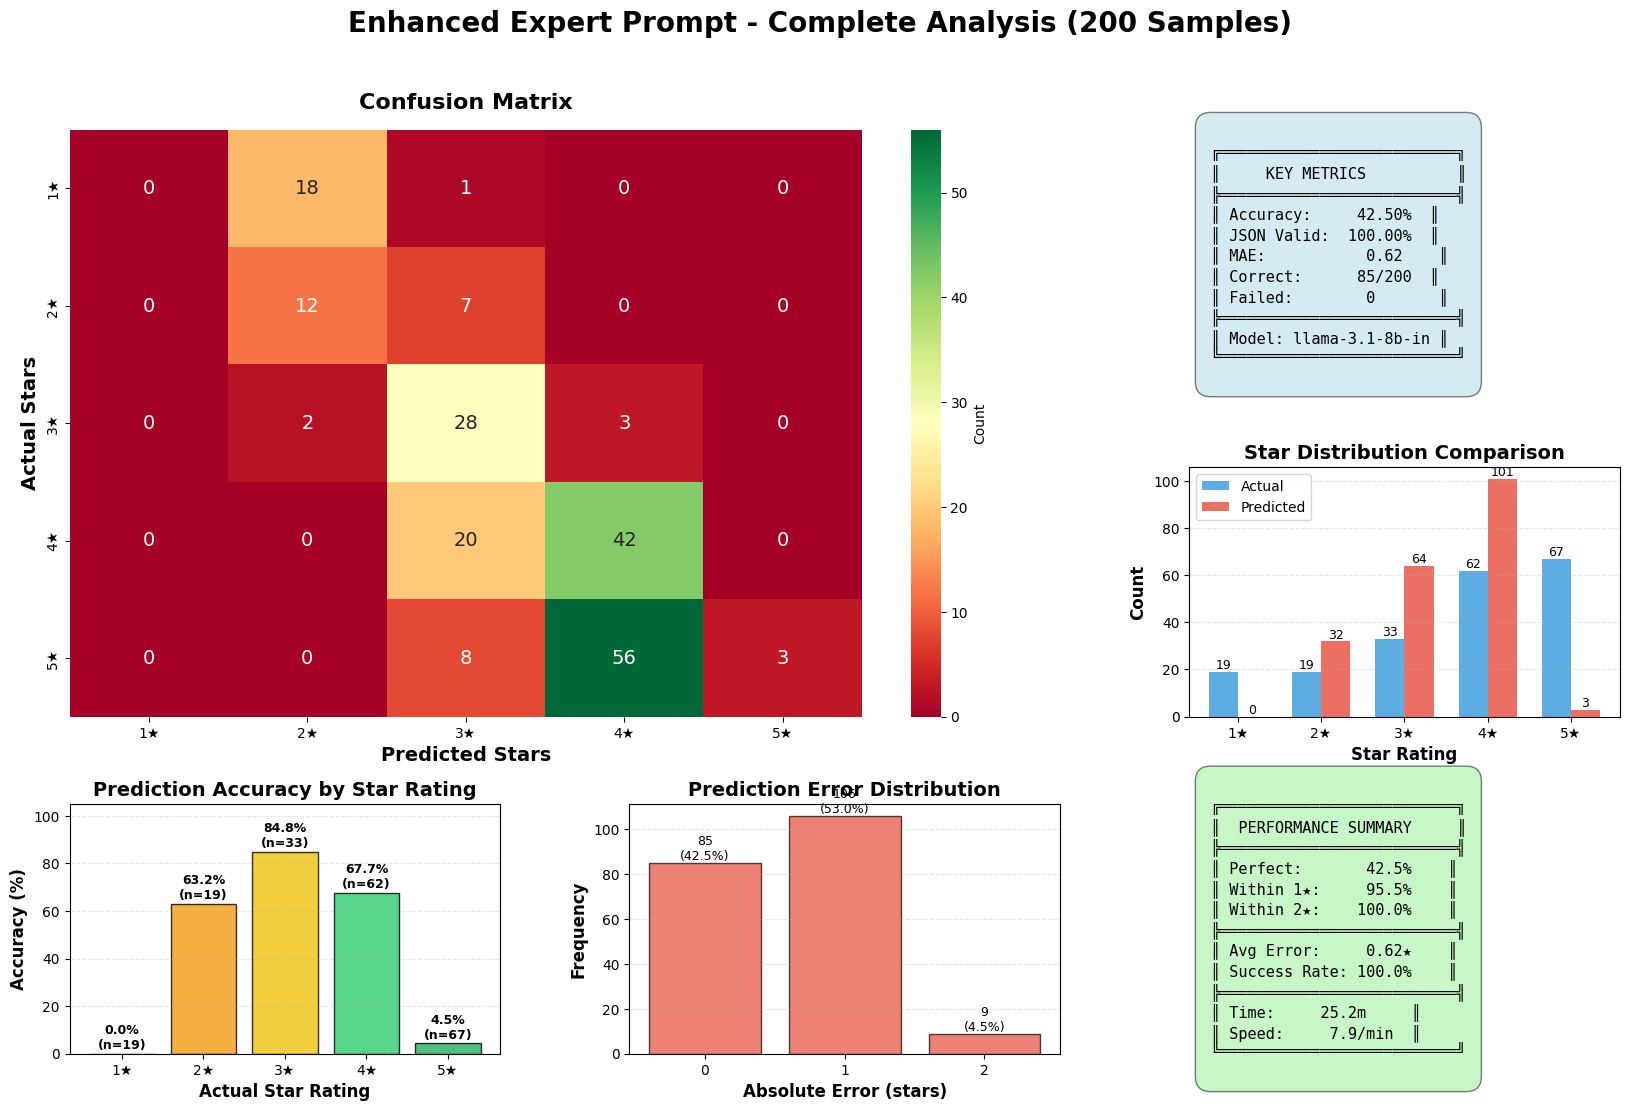


📊 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

      1-Star       0.00      0.00      0.00        19
      2-Star       0.38      0.63      0.47        19
      3-Star       0.44      0.85      0.58        33
      4-Star       0.42      0.68      0.52        62
      5-Star       1.00      0.04      0.09        67

    accuracy                           0.42       200
   macro avg       0.45      0.44      0.33       200
weighted avg       0.57      0.42      0.33       200


🎉 EVALUATION COMPLETE!
✓ Processed: 200 samples
✓ Success rate: 100.0%
✓ Accuracy: 42.50%
✓ MAE: 0.62

📁 Generated files:
   • enhanced_prompt_FINAL_200samples.csv (all results)
   • enhanced_prompt_ANALYSIS_200samples.png (visualization)
   • enhanced_prompt_checkpoint_*.csv (progress saves)

💰 Estimated token usage: ~110,000 tokens
   (Actual usage may vary)



In [7]:
def main():
    """Main execution with comprehensive error handling"""

    print("\n" + "="*80)
    print("🚀 BATTLE-TESTED ENHANCED SENTIMENT ANALYSIS")
    print("="*80)
    print("✓ Guaranteed JSON parsing")
    print("✓ Comprehensive error handling")
    print("✓ Automatic retries with backoff")
    print("✓ Progress checkpoints every 50 samples")
    print("="*80)

    # Load data
    print("\n📂 Loading and validating data...")

    if not os.path.exists('yelp.csv'):
        raise FileNotFoundError(
            "❌ yelp.csv not found in current directory!\n"
            f"   Current directory: {os.getcwd()}"
        )

    try:
        df_reviews = pd.read_csv('/content/yelp.csv')
        print(f"✅ Loaded CSV: {len(df_reviews)} rows")
    except Exception as e:
        raise Exception(f"❌ Error reading CSV: {e}")

    # Validate columns
    required_cols = ['text', 'stars']
    missing_cols = [col for col in required_cols if col not in df_reviews.columns]
    if missing_cols:
        raise ValueError(
            f"❌ Missing required columns: {missing_cols}\n"
            f"   Found columns: {list(df_reviews.columns)}"
        )

    # Clean data
    print("🧹 Cleaning data...")
    df_clean = df_reviews[['text', 'stars']].copy()
    df_clean = df_clean.dropna()
    df_clean['stars'] = pd.to_numeric(df_clean['stars'], errors='coerce')
    df_clean = df_clean.dropna()
    df_clean['stars'] = df_clean['stars'].astype(int)
    df_clean = df_clean[(df_clean['stars'] >= 1) & (df_clean['stars'] <= 5)]
    df_clean = df_clean[df_clean['text'].str.len() > 10]
    df_clean = df_clean.reset_index(drop=True)

    print(f"✅ Clean dataset: {len(df_clean)} valid reviews")

    if len(df_clean) < SAMPLE_SIZE:
        print(f"⚠️  Only {len(df_clean)} reviews available")
        sample_size = len(df_clean)
    else:
        sample_size = SAMPLE_SIZE

    # Sample data
    df_sample = df_clean.sample(n=sample_size, random_state=42).reset_index(drop=True)

    # Display configuration
    print("\n" + "="*80)
    print("⚙️  CONFIGURATION")
    print("="*80)
    print(f"🤖 Model:           {MODEL_NAME}")
    print(f"📊 Samples:         {sample_size}")
    print(f"📝 Max review len:  {MAX_REVIEW_LENGTH} words")
    print(f"⏱️  Request delay:   {DELAY_BETWEEN_REQUESTS}s")
    print(f"🔄 Max retries:     {MAX_RETRIES}")
    print(f"🌡️  Temperature:     0.2 (low = consistent)")
    print(f"⏰ Est. time:       ~{(sample_size * DELAY_BETWEEN_REQUESTS)/60:.1f} minutes")
    print("="*80)

    # Test API connection
    print("\n🔍 Testing API connection...")
    try:
        test_prompt = enhanced_expert_prompt("Great food, loved it!")
        test_response = call_groq_api_safe(test_prompt, request_number=0)
        if test_response['success']:
            print("✅ API test successful!")
            print(f"   Test prediction: {test_response['predicted_stars']} stars")
        else:
            print(f"⚠️  API test failed: {test_response.get('error', 'Unknown')}")
            print("   Continuing anyway...")
    except Exception as e:
        print(f"⚠️  API test error: {e}")
        print("   Continuing anyway...")

    # Run evaluation
    global start_time
    start_time = time.time()

    print("\n" + "="*80)
    input("Press ENTER to start evaluation (or Ctrl+C to cancel)...")
    print("="*80)

    try:
        metrics = evaluate_enhanced_prompt(df_sample, sample_size=sample_size)
    except KeyboardInterrupt:
        print("\n\n⚠️  Evaluation interrupted by user")
        return
    except Exception as e:
        print(f"\n\n❌ Evaluation error: {e}")
        import traceback
        traceback.print_exc()
        return

    # Create visualization
    if len(metrics['actuals']) > 0:
        create_visualization(metrics)
    else:
        print("⚠️  No valid predictions to visualize")

    # Detailed classification report
    if len(metrics['actuals']) >= 5:
        print("\n" + "="*80)
        print("📊 DETAILED CLASSIFICATION REPORT")
        print("="*80)
        try:
            report = classification_report(
                metrics['actuals'],
                metrics['predicted'],
                labels=[1, 2, 3, 4, 5],
                target_names=['1-Star', '2-Star', '3-Star', '4-Star', '5-Star'],
                zero_division=0
            )
            print(report)
        except Exception as e:
            print(f"⚠️  Could not generate classification report: {e}")
        print("="*80)

    # Final summary
    print("\n" + "="*80)
    print("🎉 EVALUATION COMPLETE!")
    print("="*80)
    print(f"✓ Processed: {metrics['total']} samples")
    print(f"✓ Success rate: {metrics['json_validity']:.1f}%")
    print(f"✓ Accuracy: {metrics['accuracy']:.2f}%")
    print(f"✓ MAE: {metrics['mae']:.2f}")
    print("\n📁 Generated files:")
    print("   • enhanced_prompt_FINAL_200samples.csv (all results)")
    print("   • enhanced_prompt_ANALYSIS_200samples.png (visualization)")
    print("   • enhanced_prompt_checkpoint_*.csv (progress saves)")
    print("="*80)

    # Cost estimation
    total_tokens_est = sample_size * (400 + 150)  # ~400 prompt + ~150 response
    print(f"\n💰 Estimated token usage: ~{total_tokens_est:,} tokens")
    print(f"   (Actual usage may vary)")
    print("="*80 + "\n")

# =============================================================================
# RUN
# =============================================================================
if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print("\n\n⚠️  Execution interrupted by user")
    except Exception as e:
        print(f"\n\n❌ FATAL ERROR: {e}")
        import traceback
        traceback.print_exc()